In [1]:
import numpy as np
import matplotlib.pyplot as plt
import classy

def set_academic_style():
    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Times New Roman", "DejaVu Serif", "Bitstream Vera Serif"],
        "font.size": 16,
        "axes.labelsize": 14,
        "axes.titlesize": 14,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "legend.fontsize": 10,
        "legend.frameon": False,
        "figure.dpi": 120,
        "mathtext.fontset": "cm",
        "lines.linewidth": 1.5
    })

set_academic_style()

In [2]:
# Fixed parameters
h = 0.67810
omega_b = 0.02238280
omega_cdm = 0.1201075
As = 2.100549e-09
ns = 0.9660499
tau_reio = 0.05430842

# EDE parameters - TWO CASES
w0_cases = [-0.9, -1.1]  # Quintessence-like and Phantom-like
Omega_ede_values = np.linspace(0.001, 0.09, 30)  # Ω_EDE values for color coding

# Multipole range
l_max_scalars = 2500
l_max_tensors = 600

In [3]:
# Compute ΛCDM reference spectrum only once
print("Computing ΛCDM reference spectrum...")

# Define k range and redshift for matter power spectrum (same as before)
k_min = 1e-4  # Minimum k in h/Mpc
k_max = 10.0  # Maximum k in h/Mpc
nk = 1000      # Number of k points (logarithmic spacing)
z_pk = 0.0    # Redshift for power spectrum

lcdm_params = {
    'h': h,
    'omega_b': omega_b,
    'omega_cdm': omega_cdm,
    'A_s': As,
    'n_s': ns,
    'tau_reio': tau_reio,
    'output': 'tCl,pCl,lCl,mPk',  # Added 'mPk' to output
    'modes': 's,t',
    'lensing': 'yes',
    'non linear': 'halofit',
    'r': 0.1,
    'n_t': 0,
    'l_max_scalars': l_max_scalars,
    'l_max_tensors': l_max_tensors,
    'N_ur': 2.0308,
    'N_ncdm': 1,
    'gauge': 'Newtonian',
    'P_k_max_1/Mpc': k_max/h,  # Convert to 1/Mpc (not h/Mpc)
    'z_max_pk': max(z_pk) if hasattr(z_pk, '__len__') else z_pk
}

cosmo_lcdm = classy.Class()
cosmo_lcdm.set(lcdm_params)
cosmo_lcdm.compute()

# Get lensed ΛCDM spectra
cl_lcdm = cosmo_lcdm.lensed_cl(l_max_scalars)
ell = cl_lcdm['ell'][2:]  # Skip first two multipoles

# Precompute ΛCDM spectra with proper scaling
factor = 1e10 * ell * (ell + 1) / (2 * np.pi)

cl_tt_lcdm = factor * cl_lcdm['tt'][2:]
cl_ee_lcdm = factor * cl_lcdm['ee'][2:] if 'ee' in cl_lcdm else np.zeros_like(ell)
cl_te_lcdm = factor * cl_lcdm['te'][2:] if 'te' in cl_lcdm else np.zeros_like(ell)

# Get matter power spectrum for ΛCDM
print("Getting matter power spectrum for ΛCDM...")

# Create k array (logarithmic spacing)
k_lcdm = np.logspace(np.log10(k_min), np.log10(k_max), nk)

# Get P(k) at specified redshift(s)
if hasattr(z_pk, '__len__'):
    # Multiple redshifts
    pk_lcdm_data = []
    for z in z_pk:
        pk_z = np.array([cosmo_lcdm.pk(ki * h, z) for ki in k_lcdm])  # Note: CLASS expects k in 1/Mpc
        pk_lcdm_data.append(pk_z)
    pk_lcdm = np.array(pk_lcdm_data)
else:
    # Single redshift
    pk_lcdm = np.array([cosmo_lcdm.pk(ki * h, z_pk) for ki in k_lcdm])

print("ΛCDM spectrum computed successfully!")

Computing ΛCDM reference spectrum...
Getting matter power spectrum for ΛCDM...
ΛCDM spectrum computed successfully!


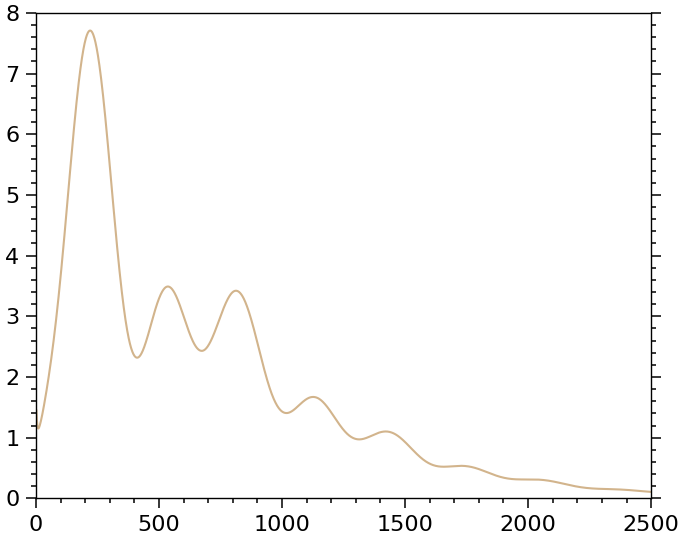

In [22]:
plt.plot(ell, cl_tt_lcdm)

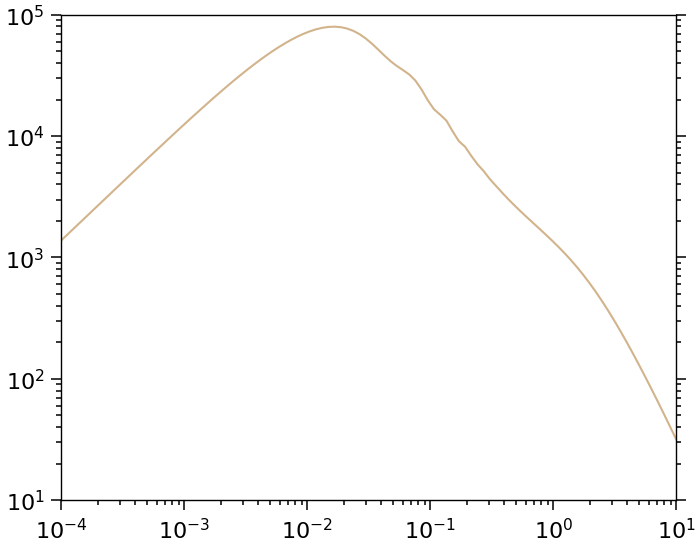

In [23]:
plt.loglog(k_lcdm, pk_lcdm)

In [4]:
# ----------------------------------------------------------------------------
# 2. COMPUTE EDE SPECTRA FOR EACH CASE
# ----------------------------------------------------------------------------
print("\n2. Computing EDE spectra...")

# Dictionary to store all results
results = {
    'ell': ell,
    'cl_tt_lcdm': cl_tt_lcdm,
    'cl_ee_lcdm': cl_ee_lcdm,
    'cl_te_lcdm': cl_te_lcdm,
    'Omega_ede_values': Omega_ede_values,
    'cases': {}
}

# Define k range and redshift for matter power spectrum
# You can adjust these values as needed
k_min = 1e-4  # Minimum k in h/Mpc
k_max = 10.0  # Maximum k in h/Mpc
nk = 1000      # Number of k points (logarithmic spacing)
z_pk = 0.0    # Redshift for power spectrum (can be array: [0.0, 1.0, ...])

# Loop through both w0 cases
for w0 in w0_cases:
    print(f"\n   Case w0 = {w0}:")
    
    # Initialize storage for this case
    case_results = {
        'w0': w0,
        'cl_tt': [],
        'cl_ee': [],
        'cl_te': [],
        'Omega_ede': [],
        'k': None,           # Will store k array
        'z_pk': z_pk,        # Redshift(s) for P(k)
        'pk': []             # Will store matter power spectra P(k,z)
    }
    
    # Compute spectra for each Ω_EDE value
    for i, Omega_ede in enumerate(Omega_ede_values):
        print(f"      Ω_EDE = {Omega_ede:.3f} ({i+1}/{len(Omega_ede_values)})")
        
        # EDE cosmology settings
        M = classy.Class()
        
        ede_settings = {
            'h': h,
            'omega_b': omega_b,
            'omega_cdm': omega_cdm,
            'A_s': As,
            'n_s': ns,
            'tau_reio': tau_reio,
            'output': 'tCl,pCl,lCl,mPk',  # Added 'mPk' to output
            'modes': 's,t',
            'lensing': 'yes',
            'non linear': 'halofit',
            'r': 0.1,
            'n_t': 0,
            'l_max_scalars': l_max_scalars,
            'l_max_tensors': l_max_tensors,
            'N_ur': 2.0308,
            'N_ncdm': 1,
            'gauge': 'Newtonian',
            'fluid_equation_of_state': 'EDE',
            'use_ppf': 'yes',
            'tol_initial_Omega_r': 0.1,
            'w0_fld': w0,
            'Omega_EDE': Omega_ede,
            'Omega_Lambda': 0.0,
            'cs2_fld': 1.0,
            'P_k_max_1/Mpc': k_max/h,  # Convert to 1/Mpc (not h/Mpc)
            'z_max_pk': max(z_pk) if hasattr(z_pk, '__len__') else z_pk
        }
        
        M.set(ede_settings)
        M.compute()
        
        # Get lensed EDE spectra
        cl_ede = M.lensed_cl(l_max_scalars)
        
        # Compute spectra with same scaling as ΛCDM
        cl_tt_ede = factor * cl_ede['tt'][2:]
        cl_ee_ede = factor * cl_ede['ee'][2:] if 'ee' in cl_ede else np.zeros_like(ell)
        cl_te_ede = factor * cl_ede['te'][2:] if 'te' in cl_ede else np.zeros_like(ell)
        
        # Get matter power spectrum
        # Create k array (logarithmic spacing)
        k = np.logspace(np.log10(k_min), np.log10(k_max), nk)
        
        # Get P(k) at specified redshift(s)
        if hasattr(z_pk, '__len__'):
            # Multiple redshifts
            pk_data = []
            for z in z_pk:
                pk_z = np.array([M.pk(ki * h, z) for ki in k])  # Note: CLASS expects k in 1/Mpc
                pk_data.append(pk_z)
            pk_data = np.array(pk_data)
        else:
            # Single redshift
            pk_data = np.array([M.pk(ki * h, z_pk) for ki in k])
        
        # Store k array only once (same for all Omega_ede values)
        if case_results['k'] is None:
            case_results['k'] = k
        
        # Store results
        case_results['cl_tt'].append(cl_tt_ede)
        case_results['cl_ee'].append(cl_ee_ede)
        case_results['cl_te'].append(cl_te_ede)
        case_results['Omega_ede'].append(Omega_ede)
        case_results['pk'].append(pk_data)
        
        # Clean up
        M.struct_cleanup()
        M.empty()
    
    # Convert lists to arrays for easier handling
    case_results['cl_tt'] = np.array(case_results['cl_tt'])
    case_results['cl_ee'] = np.array(case_results['cl_ee'])
    case_results['cl_te'] = np.array(case_results['cl_te'])
    case_results['pk'] = np.array(case_results['pk'])
    
    # Store case results
    results['cases'][w0] = case_results

# ----------------------------------------------------------------------------
# 3. CLEAN UP ΛCDM
# ----------------------------------------------------------------------------
cosmo_lcdm.struct_cleanup()
cosmo_lcdm.empty()

print("\n" + "="*60)
print("COMPUTATION COMPLETE!")
print("="*60)
print(f"Results stored in 'results' dictionary with keys:")
print(f"  - ell: multipole array")
print(f"  - cl_tt_lcdm, cl_ee_lcdm, cl_te_lcdm: ΛCDM spectra")
print(f"  - Omega_ede_values: array of Ω_EDE values")
print(f"  - cases: dictionary with results for each w0")
print(f"     • w0 = -0.9: contains cl_tt, cl_ee, cl_te arrays")
print(f"                   and k, z_pk, pk arrays for matter power spectrum")
print(f"     • w0 = -1.1: contains cl_tt, cl_ee, cl_te arrays")
print(f"                   and k, z_pk, pk arrays for matter power spectrum")
print("="*60)


2. Computing EDE spectra...

   Case w0 = -0.9:
      Ω_EDE = 0.001 (1/30)
      Ω_EDE = 0.004 (2/30)
      Ω_EDE = 0.007 (3/30)
      Ω_EDE = 0.010 (4/30)
      Ω_EDE = 0.013 (5/30)
      Ω_EDE = 0.016 (6/30)
      Ω_EDE = 0.019 (7/30)
      Ω_EDE = 0.022 (8/30)
      Ω_EDE = 0.026 (9/30)
      Ω_EDE = 0.029 (10/30)
      Ω_EDE = 0.032 (11/30)
      Ω_EDE = 0.035 (12/30)
      Ω_EDE = 0.038 (13/30)
      Ω_EDE = 0.041 (14/30)
      Ω_EDE = 0.044 (15/30)
      Ω_EDE = 0.047 (16/30)
      Ω_EDE = 0.050 (17/30)
      Ω_EDE = 0.053 (18/30)
      Ω_EDE = 0.056 (19/30)
      Ω_EDE = 0.059 (20/30)
      Ω_EDE = 0.062 (21/30)
      Ω_EDE = 0.065 (22/30)
      Ω_EDE = 0.069 (23/30)
      Ω_EDE = 0.072 (24/30)
      Ω_EDE = 0.075 (25/30)
      Ω_EDE = 0.078 (26/30)
      Ω_EDE = 0.081 (27/30)
      Ω_EDE = 0.084 (28/30)
      Ω_EDE = 0.087 (29/30)
      Ω_EDE = 0.090 (30/30)

   Case w0 = -1.1:
      Ω_EDE = 0.001 (1/30)
      Ω_EDE = 0.004 (2/30)
      Ω_EDE = 0.007 (3/30)
      Ω_EDE = 0.010

In [6]:
# ============================================================================
# PLOTTING ONLY (Run after computation is complete)
# ============================================================================

import matplotlib.pyplot as plt
import numpy as np

plt.style.reload_library()
plt.style.available

['Solarize_Light2',
 '_classic_test_patch',
 '_mpl-gallery',
 '_mpl-gallery-nogrid',
 'bmh',
 'classic',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'seaborn-v0_8',
 'seaborn-v0_8-bright',
 'seaborn-v0_8-colorblind',
 'seaborn-v0_8-dark',
 'seaborn-v0_8-dark-palette',
 'seaborn-v0_8-darkgrid',
 'seaborn-v0_8-deep',
 'seaborn-v0_8-muted',
 'seaborn-v0_8-notebook',
 'seaborn-v0_8-paper',
 'seaborn-v0_8-pastel',
 'seaborn-v0_8-poster',
 'seaborn-v0_8-talk',
 'seaborn-v0_8-ticks',
 'seaborn-v0_8-white',
 'seaborn-v0_8-whitegrid',
 'tableau-colorblind10']

In [8]:
#plt.style.use('extensys')

In [5]:
# Get data from results dictionary
ell = results['ell']
cl_tt_lcdm = results['cl_tt_lcdm']
cl_ee_lcdm = results['cl_ee_lcdm']
cl_te_lcdm = results['cl_te_lcdm']
Omega_ede_values = results['Omega_ede_values']

# Get case data
case_w09 = results['cases'][-0.9]
case_w11 = results['cases'][-1.1]

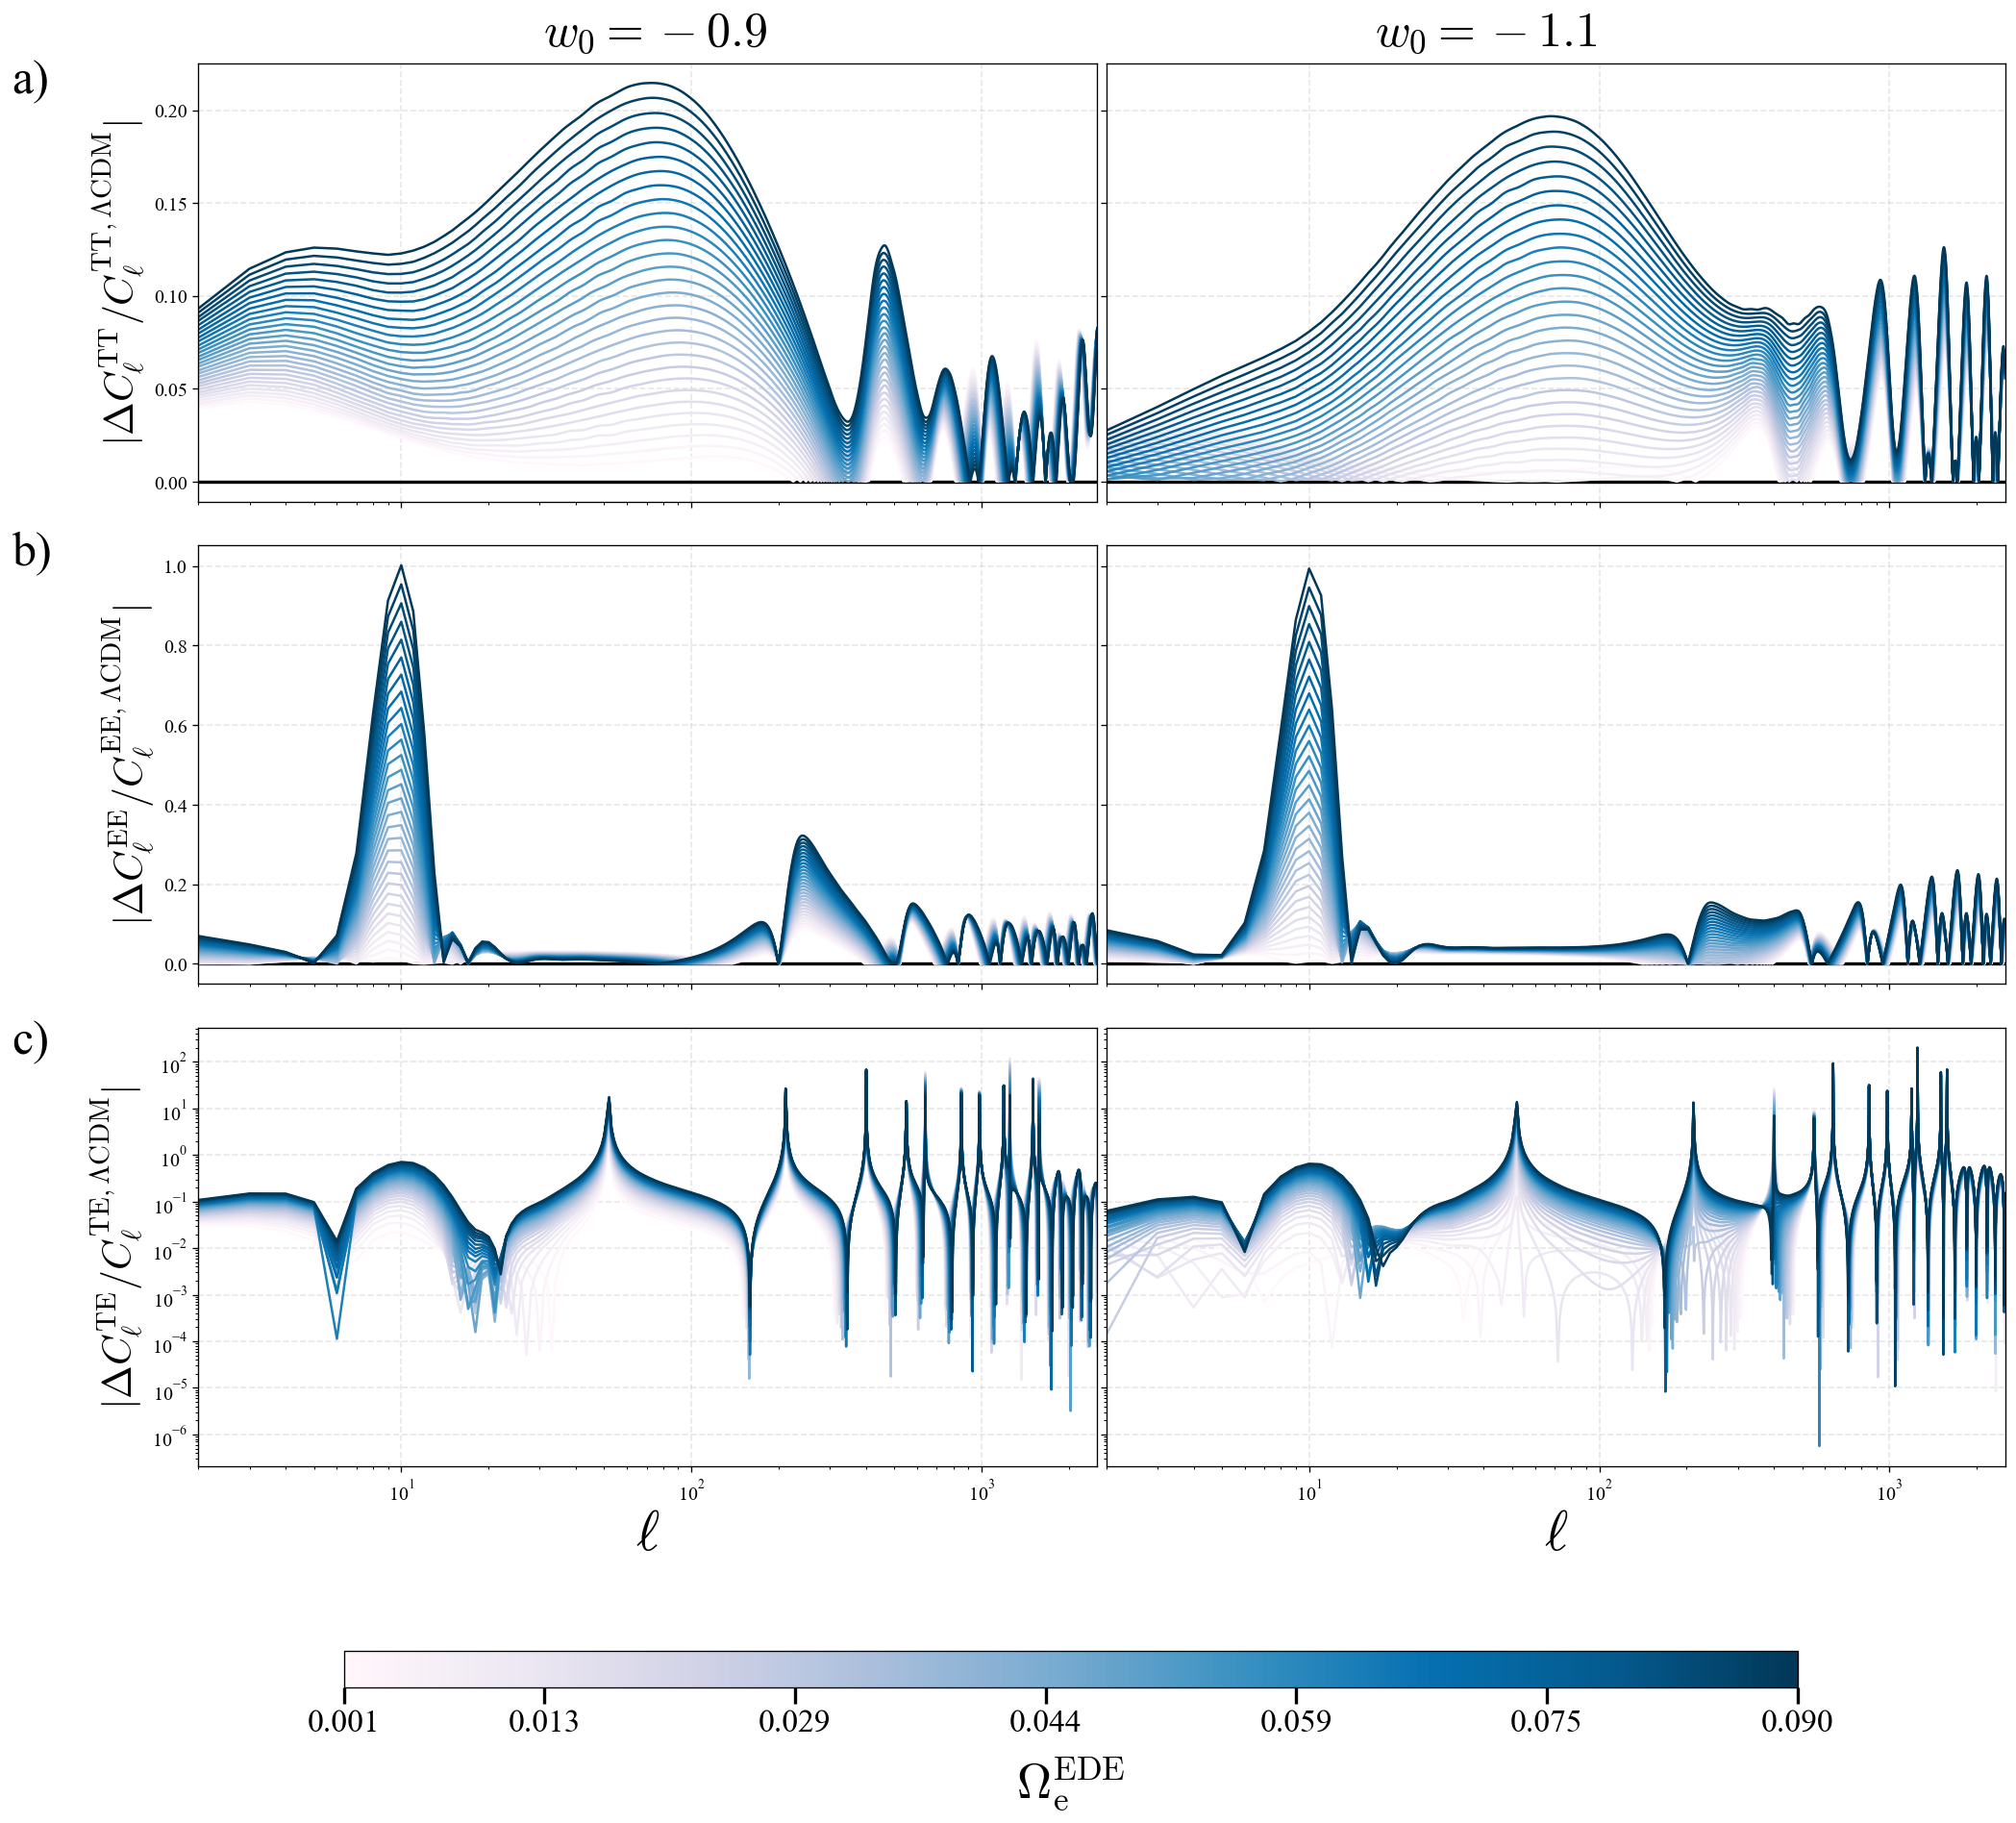

In [6]:
# Create figure with 3 rows × 2 columns, share y-axis within rows
fig, axes = plt.subplots(3, 2, figsize=(18, 16), sharex='col', sharey='row')

# Remove grids from all axes
for ax_row in axes:
    for ax in ax_row:
        ax.grid(False)
        ax.set_xscale('log')
        ax.axhline(y=0, color='black', linestyle='-', alpha=1.0, linewidth=2.0)

# Set x-limits for bottom row
for ax in axes[-1, :]:
    ax.set_xlim(2, 2500)

# Color setup - single colormap for all
cmap = plt.cm.PuBu
norm = plt.Normalize(vmin=min(Omega_ede_values), vmax=max(Omega_ede_values))
colors = [cmap(norm(Omega_ede)) for Omega_ede in Omega_ede_values]

# Small epsilon to avoid division by zero
eps = 0.0

# ----------------------------------------------------------------------------
# ROW 1: TT SPECTRUM
# ----------------------------------------------------------------------------

# TT for w0 = -0.9 (left column)
ax = axes[0, 0]
for i in range(len(Omega_ede_values)):
    tt_ratio = np.abs((case_w09['cl_tt'][i] / (cl_tt_lcdm + eps)) - 1)
    ax.semilogx(ell, tt_ratio, color=colors[i], lw=1.5, alpha=1.0)
ax.set_ylabel(r"$\vert  \Delta C_\ell^{\rm TT} / C_\ell^{\rm TT,\Lambda CDM} \vert $", fontsize=25)
ax.grid(alpha=0.3, linestyle='--', linewidth=1.0)
# TT for w0 = -1.1 (right column)
ax = axes[0, 1]
for i in range(len(Omega_ede_values)):
    tt_ratio = np.abs((case_w11['cl_tt'][i] / (cl_tt_lcdm + eps)) - 1)
    ax.semilogx(ell, tt_ratio, color=colors[i], lw=1.5, alpha=1.0)

ax.grid(alpha=0.3, linestyle='--', linewidth=1.0)
# Add row label for TT
fig.text(-0.01, 0.87, 'a)', fontsize=30,
         rotation=0, verticalalignment='center')

# Remove separation between w0 titles - set spacing to 0
fig.text(0.3, 0.89, r"$w_0 = -0.9$", fontsize=30, ha='center')
fig.text(0.7, 0.89, r"$w_0 = -1.1$", fontsize=30, ha='center')

# ----------------------------------------------------------------------------
# ROW 2: EE SPECTRUM
# ----------------------------------------------------------------------------

# EE for w0 = -0.9 (left column)
ax = axes[1, 0]
for i in range(len(Omega_ede_values)):
    ee_ratio = np.abs((case_w09['cl_ee'][i] / (cl_ee_lcdm + eps)) - 1)
    ax.semilogx(ell, ee_ratio, color=colors[i], lw=1.5, alpha=1.0)
ax.set_ylabel(r"$\vert \Delta C_\ell^{\rm EE} / C_\ell^{\rm EE,\Lambda CDM} \vert $", fontsize=25)
ax.grid(alpha=0.3, linestyle='--', linewidth=1.0)
# EE for w0 = -1.1 (right column)
ax = axes[1, 1]
for i in range(len(Omega_ede_values)):
    ee_ratio = np.abs((case_w11['cl_ee'][i] / (cl_ee_lcdm + eps)) - 1)
    ax.semilogx(ell, ee_ratio, color=colors[i], lw=1.5, alpha=1.0)

ax.grid(alpha=0.3, linestyle='--', linewidth=1.0)

# Add row label for EE
fig.text(-0.01, 0.615, 'b)', fontsize=30, 
         rotation=0, verticalalignment='center')

# ----------------------------------------------------------------------------
# ROW 3: TE SPECTRUM
# ----------------------------------------------------------------------------

# TE for w0 = -0.9 (left column)
ax = axes[2, 0]
for i in range(len(Omega_ede_values)):
    te_ratio = np.abs((case_w09['cl_te'][i] / (cl_te_lcdm + eps)) - 1)
    ax.semilogx(ell, te_ratio, color=colors[i], lw=1.5, alpha=1.0)
ax.set_ylabel(r"$ \vert \Delta C_\ell^{\rm TE} / C_\ell^{\rm TE,\Lambda CDM} \vert $", fontsize=25)
ax.set_xlabel(r"$\ell$", fontsize=35)
ax.grid(alpha=0.3, linestyle='--', linewidth=1.0)
# Set log scale for TE y-axis only
ax.set_yscale('log')

# TE for w0 = -1.1 (right column)
ax = axes[2, 1]
for i in range(len(Omega_ede_values)):
    te_ratio = np.abs((case_w11['cl_te'][i] / (cl_te_lcdm + eps)) - 1)
    ax.semilogx(ell, te_ratio, color=colors[i], lw=1.5, alpha=1.0)
ax.set_xlabel(r"$\ell$", fontsize=35)
# Set log scale for TE y-axis only
ax.set_yscale('log')
ax.grid(alpha=0.3, linestyle='--', linewidth=1.0)

# Add row label for TE
fig.text(-0.01, 0.35, 'c)', fontsize=30,
         rotation=0, verticalalignment='center')

# ----------------------------------------------------------------------------
# ADD COLORBAR AT THE BOTTOM
# ----------------------------------------------------------------------------

# Create scalar mappable for colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

# Add colorbar at the bottom (spanning both columns)
cbar_ax = fig.add_axes([0.15, 0.0, 0.7, 0.02])  # Positioned at the bottom
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
# Put Omega_EDE label below colorbar
cbar_ax.set_xlabel(r'$\Omega^{\rm EDE}_{\rm e}$', fontsize=30, labelpad=10)
cbar.ax.tick_params(labelsize=25, length=10, width=2)

# Set MORE ticks on the colorbar (show more numbers)
if len(Omega_ede_values) >= 8:
    # Show 5-7 evenly spaced ticks
    n_ticks = min(7, len(Omega_ede_values))
    tick_indices = np.linspace(0, len(Omega_ede_values)-1, n_ticks, dtype=int)
    cbar.set_ticks([Omega_ede_values[i] for i in tick_indices])
    cbar.set_ticklabels([f'{Omega_ede_values[i]:.3f}' for i in tick_indices], fontsize=20)
elif len(Omega_ede_values) >= 5:
    # Show beginning, middle, and end
    tick_indices = [0, len(Omega_ede_values)//4, len(Omega_ede_values)//2, 
                    3*len(Omega_ede_values)//4, -1]
    cbar.set_ticks([Omega_ede_values[i] for i in tick_indices])
    cbar.set_ticklabels([f'{Omega_ede_values[i]:.2f}' for i in tick_indices], fontsize=20)
else:
    # Show all values if there are few
    cbar.set_ticks(Omega_ede_values)
    cbar.set_ticklabels([f'{val:.3f}' for val in Omega_ede_values], fontsize=20)

# ----------------------------------------------------------------------------
# FINAL ADJUSTMENTS
# ----------------------------------------------------------------------------

# Adjust layout with proper spacing - reduced hspace to 0
plt.subplots_adjust(left=0.08, right=0.95, bottom=0.12, top=0.88, hspace=0.1, wspace=0.01)

plt.savefig('cmb_spectra_ede.pdf', bbox_inches='tight')

plt.show()

In [11]:
# ----------------------------------------------------------------------------
# 4. COMPUTE BACKGROUND EVOLUTION: w(z) AND rho_EDE(z)/rho_{c,0}
#    (single case: w0 = -1.0)
# ----------------------------------------------------------------------------
print("\n4. Computing background evolution (w_fld and rho_fld) for w0 = -1.0...")

# These are background-only quantities: they do not depend on A_s, n_s,
# tau_reio, l_max, or the P(k) settings used above, so we request
# output='' and skip the perturbation module entirely (much faster than
# the Cl/Pk runs).

w0 = -1.0  # single case, replaces the w0_cases loop

background_results = {
    w0: {'Omega_ede': [], 'one_plus_z': [], 'w_fld': [], 'rho_ede_ratio': []}
}

print(f"\n   Case w0 = {w0}:")

for i, Omega_ede in enumerate(Omega_ede_values):
    print(f"      Ω_EDE = {Omega_ede:.3f} ({i+1}/{len(Omega_ede_values)})")

    M = classy.Class()

    bg_settings = {
        'h': h,
        'omega_b': omega_b,
        'omega_cdm': omega_cdm,
        'output': '',                  # background/thermodynamics only
        'N_ur': 2.0308,
        'N_ncdm': 1,
        'fluid_equation_of_state': 'EDE',
        'use_ppf': 'yes',
        'tol_initial_Omega_r': 0.1,
        'w0_fld': w0,
        'Omega_EDE': Omega_ede,
        'Omega_Lambda': 0.0,
        'cs2_fld': 1.0,
    }

    M.set(bg_settings)
    M.compute()

    bg = M.get_background()

    # Column names can differ slightly across CLASS versions/builds,
    # so pick them out by pattern rather than hardcoding the string.
    z_bg     = bg['z']
    w_key    = next(k for k in bg.keys() if k.endswith('w_fld'))
    rho_key  = next(k for k in bg.keys() if k.endswith('rho_fld'))
    rhoc_key = next(k for k in bg.keys() if k.endswith('rho_crit'))

    w_fld     = bg[w_key]
    rho_fld   = bg[rho_key]
    rho_crit0 = bg[rhoc_key][np.argmin(z_bg)]     # rho_crit at z = 0

    one_plus_z = 1.0 + z_bg
    order = np.argsort(one_plus_z)                # today -> early universe

    background_results[w0]['Omega_ede'].append(Omega_ede)
    background_results[w0]['one_plus_z'].append(one_plus_z[order])
    background_results[w0]['w_fld'].append(w_fld[order])
    background_results[w0]['rho_ede_ratio'].append(rho_fld[order] / rho_crit0)

    M.struct_cleanup()
    M.empty()

print("\nBackground computation complete!")


4. Computing background evolution (w_fld and rho_fld) for w0 = -1.0...

   Case w0 = -1.0:
      Ω_EDE = 0.001 (1/30)
      Ω_EDE = 0.004 (2/30)
      Ω_EDE = 0.007 (3/30)
      Ω_EDE = 0.010 (4/30)
      Ω_EDE = 0.013 (5/30)
      Ω_EDE = 0.016 (6/30)
      Ω_EDE = 0.019 (7/30)
      Ω_EDE = 0.022 (8/30)
      Ω_EDE = 0.026 (9/30)
      Ω_EDE = 0.029 (10/30)
      Ω_EDE = 0.032 (11/30)
      Ω_EDE = 0.035 (12/30)
      Ω_EDE = 0.038 (13/30)
      Ω_EDE = 0.041 (14/30)
      Ω_EDE = 0.044 (15/30)
      Ω_EDE = 0.047 (16/30)
      Ω_EDE = 0.050 (17/30)
      Ω_EDE = 0.053 (18/30)
      Ω_EDE = 0.056 (19/30)
      Ω_EDE = 0.059 (20/30)
      Ω_EDE = 0.062 (21/30)
      Ω_EDE = 0.065 (22/30)
      Ω_EDE = 0.069 (23/30)
      Ω_EDE = 0.072 (24/30)
      Ω_EDE = 0.075 (25/30)
      Ω_EDE = 0.078 (26/30)
      Ω_EDE = 0.081 (27/30)
      Ω_EDE = 0.084 (28/30)
      Ω_EDE = 0.087 (29/30)
      Ω_EDE = 0.090 (30/30)

Background computation complete!


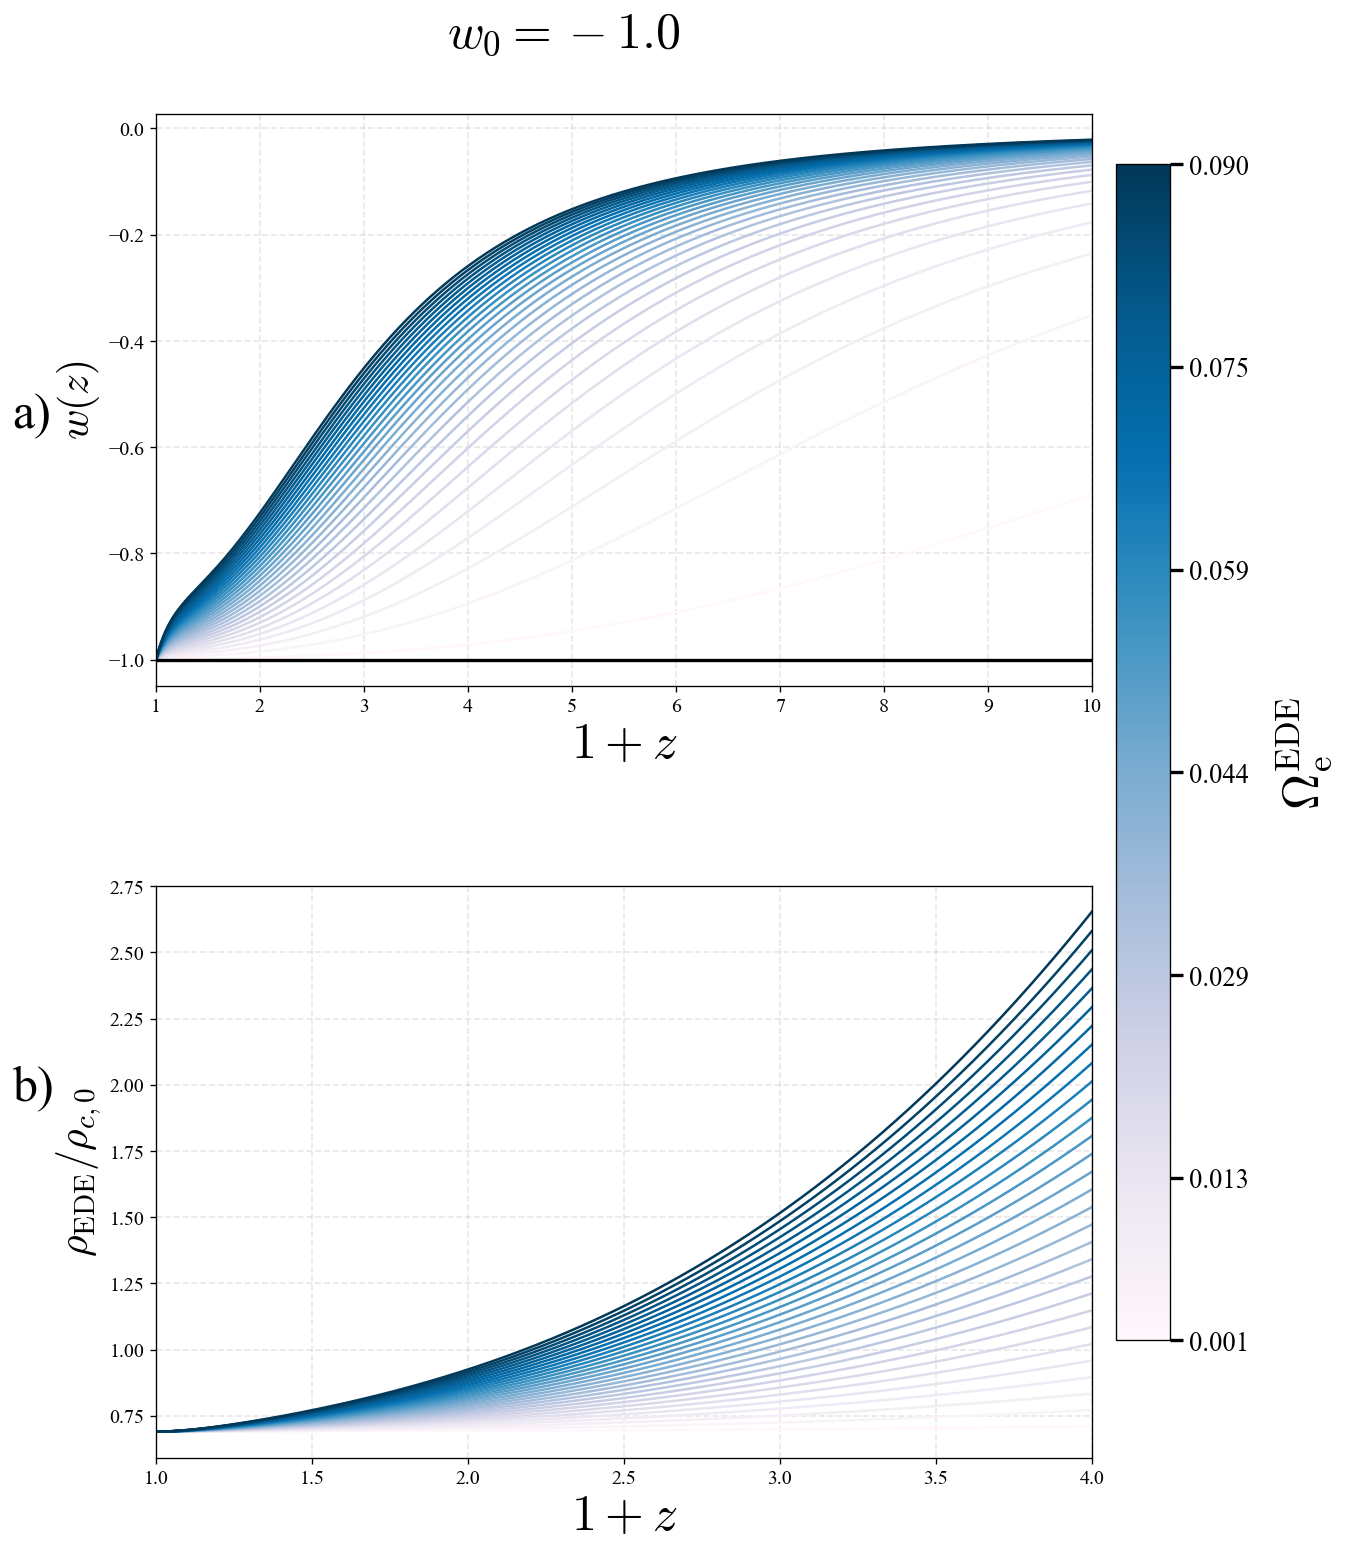

In [13]:
# ----------------------------------------------------------------------------
# PLOT: w(z) AND rho_EDE(z)/rho_{c,0} FOR w0 = -1.0 ONLY
# Single column, two rows, colorbar on the RIGHT, linear x-scale for w(z)
# ----------------------------------------------------------------------------

case_w1_bg = background_results[-1.0]

def restrict(x_list, y_list, x_min, x_max):
    """Trim each (x, y) curve to [x_min, x_max] BEFORE plotting so autoscale
    never sees the huge early-universe values outside the visible range."""
    x_out, y_out = [], []
    for x, y in zip(x_list, y_list):
        mask = (x >= x_min) & (x <= x_max)
        x_out.append(x[mask])
        y_out.append(y[mask])
    return x_out, y_out

fig, axes = plt.subplots(2, 1, figsize=(10, 14))  # different x-ranges per row -> no sharex

for ax in axes:
    ax.grid(False)

cmap = plt.cm.PuBu
norm = plt.Normalize(vmin=min(Omega_ede_values), vmax=max(Omega_ede_values))
colors = [cmap(norm(Omega_ede)) for Omega_ede in Omega_ede_values]

# ----------------------------------------------------------------------------
# ROW 1: EQUATION OF STATE w(z), LINEAR x-SCALE, 1+z in [1, 10]
# ----------------------------------------------------------------------------

x_min1, x_max1 = 1, 10
x1_r1, w1_r1 = restrict(case_w1_bg['one_plus_z'], case_w1_bg['w_fld'], x_min1, x_max1)

ax = axes[0]
for i in range(len(x1_r1)):
    ax.plot(x1_r1[i], w1_r1[i], color=colors[i], lw=1.5, alpha=1.0)
ax.axhline(y=-1, color='black', linestyle='-', alpha=1.0, linewidth=2.0)
ax.set_ylabel(r"$w(z)$", fontsize=25)
ax.set_xlabel(r"$1+z$", fontsize=30)
ax.set_xlim(x_min1, x_max1)
ax.grid(alpha=0.3, linestyle='--', linewidth=1.0)

fig.text(0.02, 0.70, 'a)', fontsize=30, rotation=0, verticalalignment='center')
fig.text(0.48, 0.92, r"$w_0 = -1.0$", fontsize=30, ha='center')

# ----------------------------------------------------------------------------
# ROW 2: NORMALIZED ENERGY DENSITY rho_EDE/rho_{c,0}, 1+z in [1, 4]
# ----------------------------------------------------------------------------

x_min2, x_max2 = 1, 4
x1_r2, rho1_r2 = restrict(case_w1_bg['one_plus_z'], case_w1_bg['rho_ede_ratio'], x_min2, x_max2)

ax = axes[1]
for i in range(len(x1_r2)):
    ax.plot(x1_r2[i], rho1_r2[i], color=colors[i], lw=1.5, alpha=1.0)
ax.set_ylabel(r"$\rho_{\rm EDE}/\rho_{c,0}$", fontsize=25)
ax.set_xlabel(r"$1+z$", fontsize=30)
ax.set_xlim(x_min2, x_max2)
ax.ticklabel_format(axis='y', style='plain')
ax.grid(alpha=0.3, linestyle='--', linewidth=1.0)

fig.text(0.02, 0.30, 'b)', fontsize=30, rotation=0, verticalalignment='center')

# ----------------------------------------------------------------------------
# COLORBAR — moved to the RIGHT, vertical
# ----------------------------------------------------------------------------

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar_ax = fig.add_axes([0.94, 0.15, 0.045, 0.7])  # [left, bottom, width, height]
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='vertical')
cbar_ax.yaxis.set_ticks_position('right')
cbar_ax.yaxis.set_label_position('right')
cbar.set_label(r'$\Omega^{\rm EDE}_{\rm e}$', fontsize=30, labelpad=15)
cbar.ax.tick_params(labelsize=18, length=8, width=2)

if len(Omega_ede_values) >= 8:
    n_ticks = min(7, len(Omega_ede_values))
    tick_indices = np.linspace(0, len(Omega_ede_values)-1, n_ticks, dtype=int)
    cbar.set_ticks([Omega_ede_values[i] for i in tick_indices])
    cbar.set_ticklabels([f'{Omega_ede_values[i]:.3f}' for i in tick_indices], fontsize=16)
elif len(Omega_ede_values) >= 5:
    tick_indices = [0, len(Omega_ede_values)//4, len(Omega_ede_values)//2,
                    3*len(Omega_ede_values)//4, -1]
    cbar.set_ticks([Omega_ede_values[i] for i in tick_indices])
    cbar.set_ticklabels([f'{Omega_ede_values[i]:.2f}' for i in tick_indices], fontsize=16)
else:
    cbar.set_ticks(Omega_ede_values)
    cbar.set_ticklabels([f'{val:.3f}' for val in Omega_ede_values], fontsize=16)

plt.subplots_adjust(left=0.14, right=0.92, bottom=0.08, top=0.88, hspace=0.35)

plt.savefig('ede_background_w_rho_w0m1.pdf', bbox_inches='tight')

plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Create figure with 1 row × 2 columns, share y-axis within row
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True, sharey=True)

# Remove grids from all axes
for ax in axes:
    ax.grid(False)
    ax.set_xscale('log')
    #ax.set_yscale('log')
    # Optional: Add zero line if needed
    # ax.axhline(y=0, color='black', linestyle='-', alpha=1.0, linewidth=2.0)

# Set x-limits
for ax in axes:
    ax.set_xlim(min(k_lcdm), max(k_lcdm))

# Color setup - single colormap for all
cmap = plt.cm.Wistia
norm = plt.Normalize(vmin=min(Omega_ede_values), vmax=max(Omega_ede_values))
colors = [cmap(norm(Omega_ede)) for Omega_ede in Omega_ede_values]

# Small epsilon to avoid division by zero
eps = 1e-30

# ----------------------------------------------------------------------------
# LEFT PANEL: P(k) for w0 = -0.9
# ----------------------------------------------------------------------------
ax = axes[0]

# Get ΛCDM P(k) reference (assuming single redshift for simplicity)
if pk_lcdm.ndim == 1:
    pk_lcdm_ref = pk_lcdm
else:
    pk_lcdm_ref = pk_lcdm[0]  # Take first redshift if multiple

# Get EDE case for w0 = -0.9
case_w09 = results['cases'][-0.9]

# Plot P(k) ratios for w0 = -0.9
for i in range(len(Omega_ede_values)):
    # Get EDE P(k) for this Omega_ede (assuming single redshift)
    if case_w09['pk'].ndim == 2:
        pk_ede = case_w09['pk'][i]  # Shape: (n_Omega_ede, nk)
    else:
        pk_ede = case_w09['pk'][i, 0]  # Shape: (n_Omega_ede, nz, nk) -> take z=0
    
    # Compute ratio: P_EDE(k)/P_LCDM(k)
    pk_ratio = pk_ede / (pk_lcdm_ref + eps)
    
    # Plot
    ax.semilogx(case_w09['k'], pk_ratio, color=colors[i], lw=2.0, alpha=1.0)

ax.set_ylabel(r"$P_{\rm EDE}(k) / P_{\Lambda\rm{CDM}}(k)$", fontsize=25)
ax.set_xlabel(r"$k \,[h\,{\rm Mpc}^{-1}]$", fontsize=25)
ax.set_title(r"$w_0 = -0.9$", fontsize=28, pad=20)

# Add panel label
ax.text(0.02, 0.98, 'a)', transform=ax.transAxes, fontsize=30,
        verticalalignment='top', horizontalalignment='left',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

# ----------------------------------------------------------------------------
# RIGHT PANEL: P(k) for w0 = -1.1
# ----------------------------------------------------------------------------
ax = axes[1]

# Get EDE case for w0 = -1.1
case_w11 = results['cases'][-1.1]

# Plot P(k) ratios for w0 = -1.1
for i in range(len(Omega_ede_values)):
    # Get EDE P(k) for this Omega_ede (assuming single redshift)
    if case_w11['pk'].ndim == 2:
        pk_ede = case_w11['pk'][i]  # Shape: (n_Omega_ede, nk)
    else:
        pk_ede = case_w11['pk'][i, 0]  # Shape: (n_Omega_ede, nz, nk) -> take z=0
    
    # Compute ratio: P_EDE(k)/P_LCDM(k)
    pk_ratio = pk_ede / (pk_lcdm_ref + eps)
    
    # Plot
    ax.semilogx(case_w11['k'], pk_ratio, color=colors[i], lw=2.0, alpha=1.0)

ax.set_xlabel(r"$k \,[h\,{\rm Mpc}^{-1}]$", fontsize=25)
ax.set_title(r"$w_0 = -1.1$", fontsize=28, pad=20)

# Add panel label
ax.text(0.02, 0.98, 'b)', transform=ax.transAxes, fontsize=30,
        verticalalignment='top', horizontalalignment='left',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

# Add horizontal line at y=1 for reference
for ax in axes:
    ax.axhline(y=1.0, color='black', linestyle='--', alpha=0.5, linewidth=1.5)

# ----------------------------------------------------------------------------
# ADD COLORBAR AT THE BOTTOM
# ----------------------------------------------------------------------------

# Create scalar mappable for colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

# Add colorbar at the bottom (spanning both columns)
cbar_ax = fig.add_axes([0.15, 0.05, 0.7, 0.02])  # Positioned at the bottom
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
# Put Omega_EDE label below colorbar
cbar_ax.set_xlabel(r'$\Omega^{\rm EDE}_{\rm e}$', fontsize=30, labelpad=10)
cbar.ax.tick_params(labelsize=25, length=10, width=2)

# Set MORE ticks on the colorbar (show more numbers)
if len(Omega_ede_values) >= 8:
    # Show 5-7 evenly spaced ticks
    n_ticks = min(7, len(Omega_ede_values))
    tick_indices = np.linspace(0, len(Omega_ede_values)-1, n_ticks, dtype=int)
    cbar.set_ticks([Omega_ede_values[i] for i in tick_indices])
    cbar.set_ticklabels([f'{Omega_ede_values[i]:.3f}' for i in tick_indices], fontsize=20)
elif len(Omega_ede_values) >= 5:
    # Show beginning, middle, and end
    tick_indices = [0, len(Omega_ede_values)//4, len(Omega_ede_values)//2, 
                    3*len(Omega_ede_values)//4, -1]
    cbar.set_ticks([Omega_ede_values[i] for i in tick_indices])
    cbar.set_ticklabels([f'{Omega_ede_values[i]:.2f}' for i in tick_indices], fontsize=20)
else:
    # Show all values if there are few
    cbar.set_ticks(Omega_ede_values)
    cbar.set_ticklabels([f'{val:.3f}' for val in Omega_ede_values], fontsize=20)

# ----------------------------------------------------------------------------
# FINAL ADJUSTMENTS
# ----------------------------------------------------------------------------

# Add some padding to y-axis limits
for ax in axes:
    ylim = ax.get_ylim()
    # For log scale, we typically want to show a reasonable range
    # Let's set manual limits if needed
    ax.set_ylim(0.8, 1.2)  # Adjust these values based on your data range

plt.subplots_adjust(left=0.08, right=0.95, bottom=0.15, top=0.90, wspace=0.05)

plt.savefig('matter_power_spectrum_ede.pdf', bbox_inches='tight', dpi=300)
plt.show()

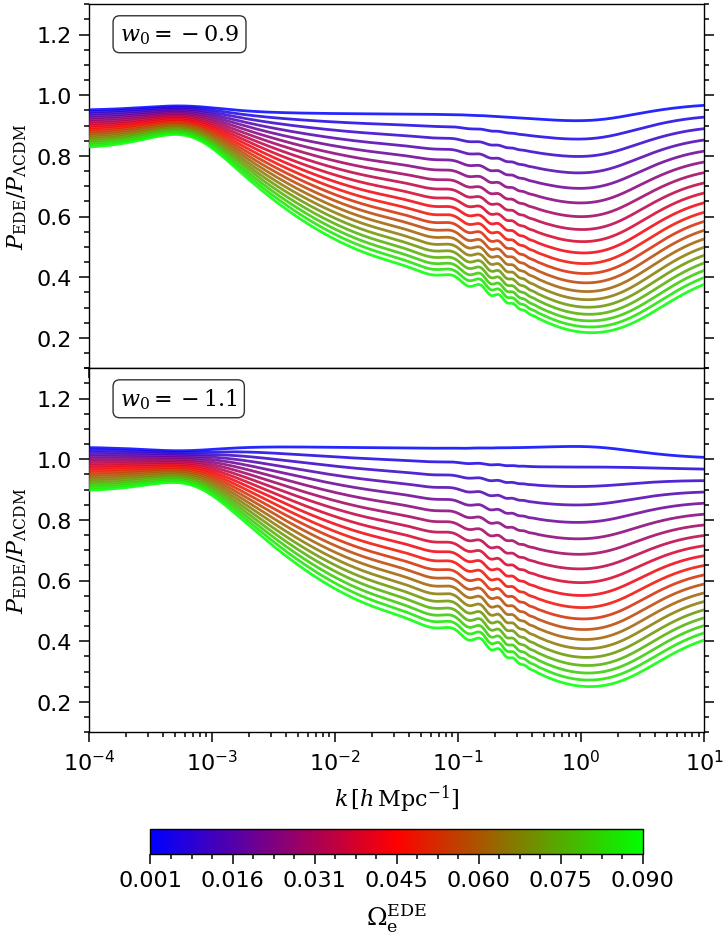

In [61]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# --- IMPORTANTE: TU ESTILO ---
# plt.style.use('extensys')

# 1. Configuración de la figura VERTICAL (2 filas, 1 columna)
# Añadimos hspace=0 para eliminar espacio vertical entre subplots
fig, axes = plt.subplots(2, 1, figsize=(8, 12), sharex=True, gridspec_kw={'hspace': 0})

# 2. Configuración de Colores 
cmap = plt.cm.brg
norm = plt.Normalize(vmin=min(Omega_ede_values), vmax=max(Omega_ede_values))
eps = 1e-30

# --- BUCLE DE PLOTEO ---
w0_vals = [-0.9, -1.1]

# Iteramos sobre los ejes verticales
for i, (ax, w0) in enumerate(zip(axes, w0_vals)):
    case = results['cases'][w0]
    
    # Plotear cada línea de Omega_ede
    for j, Omega_ede in enumerate(Omega_ede_values):
        # Obtener P(k) para EDE
        if case['pk'].ndim == 1:
            pk_ede = case['pk']
        elif case['pk'].ndim == 2:
            pk_ede = case['pk'][j]
        else:
            pk_ede = case['pk'][j, 0]
        
        # Asegurar que k arrays sean compatibles
        if len(case['k']) == len(k_lcdm) and np.allclose(case['k'], k_lcdm):
            # Calcular ratio y luego residual absoluto
            ratio = pk_ede / (pk_lcdm + eps)
            residual =  ratio
        
        # Obtenemos el color del colormap
        color = cmap(norm(Omega_ede))
        ax.semilogx(case['k'], residual, color=color, alpha=0.85, linewidth=2.0, zorder=3)

    # Etiqueta w0 dentro del plot (esquina superior izquierda)
    ax.text(0.05, 0.95, r"$w_0 = " + f"{w0}$", 
            transform=ax.transAxes, fontsize=16,
            verticalalignment='top', horizontalalignment='left',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
    
    # Etiqueta del eje Y
    ax.set_ylabel(r"$P_{\rm EDE}/P_{\Lambda\rm{CDM}}$", fontsize=16)
    
    # Remover etiquetas X del panel superior (compartido)
    if i == 0:
        ax.tick_params(axis='x', labelbottom=False)
    else:
        ax.set_xlabel(r"$k \,[h\,{\rm Mpc}^{-1}]$", fontsize=16)

# Configurar límites del eje x usando k_lcdm (compartido)
axes[0].set_xlim(min(k_lcdm), max(k_lcdm))
axes[0].set_ylim(0.1, 1.3)
axes[1].set_ylim(0.1, 1.3)

# --- BARRA DE COLOR HORIZONTAL ABAJO ---
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
# Ajuste final del layout para asegurar que estén pegados
plt.subplots_adjust(hspace=0)

# location='bottom' coloca la barra debajo de los dos paneles verticales
cbar = fig.colorbar(sm, ax=axes, location='bottom', aspect=20, shrink=0.8, pad=0.1)
cbar.set_label(r'$\Omega^{\rm EDE}_{\rm e}$', fontsize=18, labelpad=8)

# Ajustar ticks de la barra de color
if len(Omega_ede_values) > 8:
    tick_locs = np.linspace(min(Omega_ede_values), max(Omega_ede_values), 7)
else:
    tick_locs = Omega_ede_values
cbar.set_ticks(tick_locs)
cbar.set_ticklabels([f'{val:.3f}' for val in tick_locs])


plt.savefig('matter_spectra_ede.pdf', bbox_inches='tight')
plt.show()